### Pergunta 7 - Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo? ###


,feature_clean,importance_mean,importance_std
0,inde_num,3.191734,0.353822
1,iaa,0.415389,0.070163
2,ida,0.141801,0.033382
3,ieg,0.085413,0.021248
4,ips,0.059274,0.029199
5,ian,0.040922,0.016139
6,ipp,0.001040,0.008004


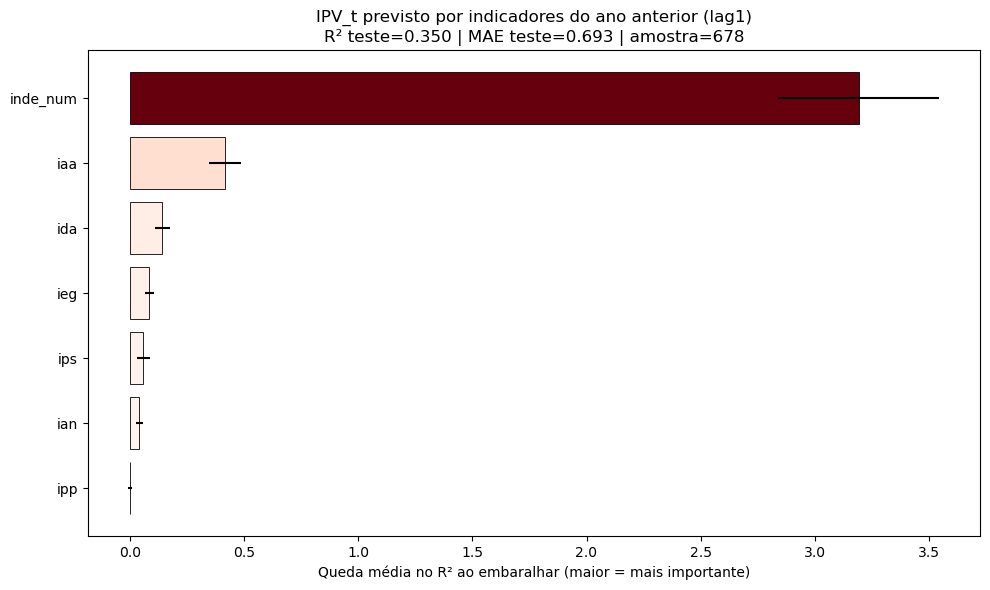

,feature_clean,importance_mean,importance_std
0,inde_num,31.453127,1.920216
1,ida,5.948196,0.510018
2,iaa,4.960609,0.321645
3,ieg,3.654234,0.298603
4,ian,3.201945,0.257058
5,ips,2.501669,0.139526
6,ipp,0.432488,0.026624


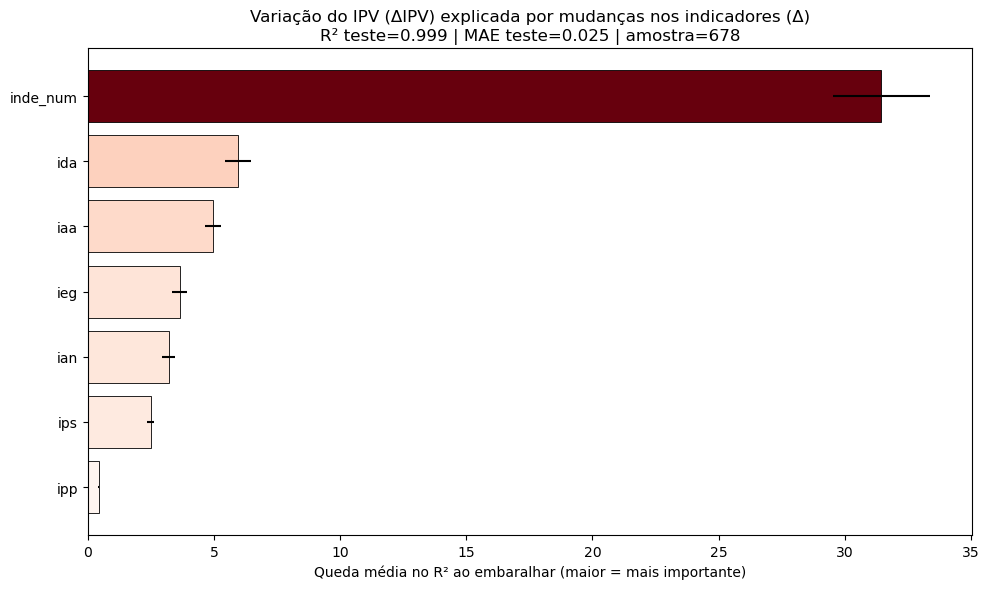

,indicador,ipv_q1,ipv_q4,delta_q4_q1
0,inde_num,6.508284,8.441638,1.933354
5,ipp,6.811824,8.467362,1.655539
2,ida,6.674348,8.285430,1.611082
1,ieg,6.710492,8.215071,1.504580
4,ips,7.624111,7.981164,0.357054
3,iaa,7.335264,7.691983,0.356719
6,ian,7.420423,7.726608,0.306185


In [24]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

CAMINHO_ARQUIVO = r"https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
df = pd.read_excel(CAMINHO_ARQUIVO, sheet_name="Sheet1")

RANDOM_STATE = 42
TEST_SIZE = 0.25
N_REPEATS_PERM = 20
TOPN_GRAFICO = 10

# FUNÇÕES AUXILIARES
def normalize_idade(val):
    if pd.isna(val):
        return np.nan

    if isinstance(val, (dt.datetime, dt.date)):
        if val.year == 1900:
            return float(val.day)
        return np.nan

    s = str(val).strip().lower()
    s = s.replace("anos", "").replace("ano", "").replace(",", ".").strip()
    try:
        return float(s)
    except Exception:
        return np.nan

# def save_barh_importance(df_imp, title, out_png=None, topn=10, label_col="feature"):
#     plot_df = df_imp.head(topn).iloc[::-1]
#     plt.figure(figsize=(10, 6))
#     plt.barh(plot_df[label_col], plot_df["importance_mean"], xerr=plot_df["importance_std"],color="#E10600")
#     plt.xlabel("Queda média no R² ao embaralhar (maior = mais importante)")
#     plt.title(title)
#     plt.tight_layout()

#     if out_png:
#         plt.savefig(out_png, dpi=200, bbox_inches="tight")

#     plt.show()
#     plt.close()

import matplotlib.cm as cm
import matplotlib.colors as mcolors

def save_barh_importance(df_imp, title, out_png=None, topn=10, label_col="feature"):
    plot_df = df_imp.head(topn).iloc[::-1]

    plt.figure(figsize=(10, 6))

    norm = mcolors.Normalize(
        vmin=plot_df["importance_mean"].min(),
        vmax=plot_df["importance_mean"].max()
    )

    colors = cm.Reds(norm(plot_df["importance_mean"]))

    plt.barh(
        plot_df[label_col],
        plot_df["importance_mean"],
        xerr=plot_df["importance_std"],
        color=colors,
        edgecolor="black",
        linewidth=0.6
    )

    plt.xlabel("Queda média no R² ao embaralhar (maior = mais importante)")
    plt.title(title)
    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()


def quartil_uplift(df_in, col, target="ipv"):
    tmp = df_in[[col, target]].dropna().copy()
    tmp["quartil"] = pd.qcut(tmp[col], 4, duplicates="drop")
    out = tmp.groupby("quartil", observed=False)[target].mean().reset_index()
    out["indicador"] = col
    return out


def compute_q1_q4_delta(uplift_df, indicador, target_col="ipv"):
    tmp = uplift_df[uplift_df["indicador"] == indicador].copy()
    tmp["quartil_str"] = tmp["quartil"].astype(str)
    tmp["left"] = tmp["quartil_str"].str.extract(r"\(([-\d\.]+),").astype(float)
    tmp = tmp.sort_values("left")
    q1 = float(tmp.iloc[0][target_col])
    q4 = float(tmp.iloc[-1][target_col])
    return q1, q4, (q4 - q1)


# 1) PREP
df = pd.read_excel(CAMINHO_ARQUIVO, sheet_name="Sheet1")

df["idade_num"] = df["idade"].apply(normalize_idade) if "idade" in df.columns else np.nan
df["inde_num"] = pd.to_numeric(df["inde"], errors="coerce") if "inde" in df.columns else np.nan

# DEFININDO VARIÁVEIS
beh_vars = [
    "iaa", "ieg", "ips", "ipp", "ida", "ian",
    "inde_num"
]
beh_vars = [c for c in beh_vars if c in df.columns]

df_long = df.sort_values(["ra", "ano_aba"]).copy()

# cria lag1 dos comportamentos
for c in beh_vars:
    df_long[f"{c}_lag1"] = df_long.groupby("ra")[c].shift(1)

lag_features = [f"{c}_lag1" for c in beh_vars]

# alvo: IPV do ano t
target = "ipv"
if target not in df_long.columns:
    raise ValueError("Coluna 'ipv' não encontrada. Verifique sua base.")

lag_data = df_long.dropna(subset=lag_features + [target]).copy()

X = lag_data[lag_features]
y = lag_data[target]
groups = lag_data["ra"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), lag_features)
])

model_lag = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# 2) MODELO LAG1 + IMPORTÂNCIA
model_lag.fit(X_train, y_train)
pred = model_lag.predict(X_test)

r2_lag = r2_score(y_test, pred)
mae_lag = mean_absolute_error(y_test, pred)

perm_lag = permutation_importance(
    model_lag, X_test, y_test,
    n_repeats=N_REPEATS_PERM,
    random_state=RANDOM_STATE,
    scoring="r2"
)

imp_lag = (pd.DataFrame({
    "feature": lag_features,
    "importance_mean": perm_lag.importances_mean,
    "importance_std": perm_lag.importances_std, 
})
.sort_values("importance_mean", ascending=False)
.reset_index(drop=True))

imp_lag["feature_clean"] = imp_lag["feature"].str.replace(r"_lag1$", "", regex=True)

title_lag = (
    "IPV_t previsto por indicadores do ano anterior (lag1)\n"
    f"R² teste={r2_lag:.3f} | MAE teste={mae_lag:.3f} | amostra={len(lag_data)}"
)

display(imp_lag[["feature_clean", "importance_mean", "importance_std"]].head(10))
save_barh_importance(imp_lag, title_lag, out_png=None, topn=TOPN_GRAFICO, label_col="feature_clean")


# 3) MODELO DELTA (ΔIPV) + IMPORTÂNCIA
df_long["ipv_lag1"] = df_long.groupby("ra")[target].shift(1)
df_long["delta_ipv"] = df_long[target] - df_long["ipv_lag1"]

for c in beh_vars:
    df_long[f"delta_{c}"] = df_long[c] - df_long[f"{c}_lag1"]

delta_features = [f"delta_{c}" for c in beh_vars]

delta_data = df_long.dropna(subset=delta_features + ["delta_ipv"]).copy()

X2 = delta_data[delta_features]
y2 = delta_data["delta_ipv"]
groups2 = delta_data["ra"]

gss2 = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx2, test_idx2 = next(gss2.split(X2, y2, groups=groups2))

X2_train, X2_test = X2.iloc[train_idx2], X2.iloc[test_idx2]
y2_train, y2_test = y2.iloc[train_idx2], y2.iloc[test_idx2]

preprocess2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), delta_features)
])

model_delta = Pipeline([
    ("preprocess", preprocess2),
    ("model", LinearRegression())
])

model_delta.fit(X2_train, y2_train)
pred2 = model_delta.predict(X2_test)

r2_delta = r2_score(y2_test, pred2)
mae_delta = mean_absolute_error(y2_test, pred2)

perm_delta = permutation_importance(
    model_delta, X2_test, y2_test,
    n_repeats=N_REPEATS_PERM,
    random_state=RANDOM_STATE,
    scoring="r2"
)

imp_delta = (pd.DataFrame({
    "feature": delta_features,
    "importance_mean": perm_delta.importances_mean,
    "importance_std": perm_delta.importances_std
})
.sort_values("importance_mean", ascending=False)
.reset_index(drop=True))

imp_delta["feature_clean"] = imp_delta["feature"].str.replace(r"^delta_", "", regex=True)

title_delta = (
    "Variação do IPV (ΔIPV) explicada por mudanças nos indicadores (Δ)\n"
    f"R² teste={r2_delta:.3f} | MAE teste={mae_delta:.3f} | amostra={len(delta_data)}"
)

display(imp_delta[["feature_clean", "importance_mean", "importance_std"]].head(10))
save_barh_importance(imp_delta, title_delta, out_png=None, topn=TOPN_GRAFICO, label_col="feature_clean")


# 4) UPLIFT POR QUARTIS (efeito degrau)
uplift_cols = [c for c in ["inde_num", "ieg", "ida", "iaa", "ips", "ipp", "ian"] if c in df.columns]

uplift_list = [quartil_uplift(df, c, target=target) for c in uplift_cols]
uplift_df = pd.concat(uplift_list, ignore_index=True) if uplift_list else pd.DataFrame()

# resumo Q1 -> Q4
resumo = []
for c in uplift_cols:
    q1, q4, delta = compute_q1_q4_delta(uplift_df, c, target_col=target)
    resumo.append([c, q1, q4, delta])

resumo_df = pd.DataFrame(resumo, columns=["indicador", "ipv_q1", "ipv_q4", "delta_q4_q1"])
display(resumo_df.sort_values("delta_q4_q1", ascending=False))

### Pergunta 10 - Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa? ###

In [13]:
# 1) CONFIG

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CAMINHO_ARQUIVO = r"https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
df = pd.read_excel(CAMINHO_ARQUIVO, sheet_name="Sheet1")

ANOS_CICLO = [2022, 2023, 2024]  # ajuste se seu ciclo for outro

# Fases do programa
FASES_VALIDAS = ["Quartzo", "Ágata", "Ametista", "Topázio"]

MAP_FASE = {"Agata": "Ágata", "Topazio": "Topázio"}

# Indicadores-chave para efetividade do programa
INDICADORES = {
    "ipv": "IPV",
    "inde": "INDE",
    "ieg": "IEG (Engajamento)",
    "ida": "IDA (Socioemocional)"
}

# 2) FUNÇÕES

def normaliza_fase(x):
    s = str(x).strip().title()
    return MAP_FASE.get(s, s)

def plot_por_fase(agg, col, ylabel, title, outpath=None):

    plt.figure(figsize=(10, 5))
    for fase in sorted(agg["fase_programa"].unique()):
        sub = agg[agg["fase_programa"] == fase].sort_values("ano")
        plt.plot(sub["ano"], sub[col], marker="o", label=fase)

    plt.xlabel("Ano")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if outpath:
        plt.savefig(outpath, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()

def deltas_por_fase(agg, col, anos):

    piv = agg.pivot_table(index="fase_programa", columns="ano", values=col, aggfunc="mean")
    out = pd.DataFrame(index=piv.index)

    a, b, c = anos
    out[str(a)] = piv.get(a)
    out[str(b)] = piv.get(b)
    out[str(c)] = piv.get(c)

    out[f"Δ{a}→{b}"] = out[str(b)] - out[str(a)]
    out[f"Δ{b}→{c}"] = out[str(c)] - out[str(b)]
    out[f"Δ{a}→{c}"] = out[str(c)] - out[str(a)]

    out["Cresceu 2 anos seguidos?"] = np.where(
        (out[f"Δ{a}→{b}"] > 0) & (out[f"Δ{b}→{c}"] > 0),
        "Sim", "Não"
    )
    out = out.reset_index().rename(columns={"fase_programa": "Fase (Pedra)"})
    return out

def consistencia_por_fase(agg, anos, indicadores_dict):

    a, b, c = anos
    rows = []
    for fase in sorted(agg["fase_programa"].unique()):
        sub = agg[agg["fase_programa"] == fase].sort_values("ano")
        # garante que existem os 3 anos
        if set(sub["ano"].dropna().astype(int)) != set(anos):
            continue

        for col, label in indicadores_dict.items():
            y = sub[col].values.astype(float)
            d1 = y[1] - y[0]
            d2 = y[2] - y[1]
            overall = y[2] - y[0]
            rows.append({
                "Fase (Pedra)": fase,
                "Indicador": label,
                str(a): y[0],
                str(b): y[1],
                str(c): y[2],
                f"Δ{a}→{b}": d1,
                f"Δ{b}→{c}": d2,
                f"Δ{a}→{c}": overall,
                "Sem queda no ciclo?": "Sim" if (d1 >= 0 and d2 >= 0) else "Não",
                "Melhora no ciclo?": "Sim" if (overall > 0) else "Não"
            })

    detalhe = pd.DataFrame(rows)

    resumo = (detalhe.groupby("Fase (Pedra)")
              .agg(
                  indicadores_melhoraram=("Melhora no ciclo?", lambda s: int((s == "Sim").sum())),
                  indicadores_sem_queda=("Sem queda no ciclo?", lambda s: int((s == "Sim").sum()))
              )
              .reset_index())

    total = len(indicadores_dict)
    resumo["Indicadores avaliados"] = total
    resumo["% melhoraram (último>primeiro)"] = resumo["indicadores_melhoraram"] / total
    resumo["% sem queda (sempre subiu)"] = resumo["indicadores_sem_queda"] / total

    return detalhe, resumo

# 3) LEITURA E PREP

df = pd.read_excel(CAMINHO_ARQUIVO, sheet_name="Sheet1")

df["ano"] = pd.to_numeric(df["ano_aba"], errors="coerce")
df["fase_programa"] = df["pedra"].apply(normaliza_fase)

df = df[df["fase_programa"].isin(FASES_VALIDAS)].copy()
df = df[df["ano"].isin(ANOS_CICLO)].copy()

df["ipv"]  = pd.to_numeric(df["ipv"], errors="coerce")
df["inde"] = pd.to_numeric(df["inde"], errors="coerce")
df["ieg"]  = pd.to_numeric(df["ieg"], errors="coerce")
df["ida"]  = pd.to_numeric(df["ida"], errors="coerce")

# 4) AGREGADO FASE x ANO

agg = (df.groupby(["fase_programa", "ano"])
       .agg(
           alunos=("ra", "nunique"),
           ipv=("ipv", "mean"),
           inde=("inde", "mean"),
           ieg=("ieg", "mean"),
           ida=("ida", "mean")
       )
       .reset_index())

# 5) DELTAS POR FASE

ipv_d = deltas_por_fase(agg, "ipv", ANOS_CICLO)
inde_d = deltas_por_fase(agg, "inde", ANOS_CICLO)
ieg_d = deltas_por_fase(agg, "ieg", ANOS_CICLO)
ida_d = deltas_por_fase(agg, "ida", ANOS_CICLO)

# 6) CONSISTÊNCIA (melhora no ciclo / sem queda)

detalhe_cons, resumo_cons = consistencia_por_fase(agg, ANOS_CICLO, INDICADORES)

# Prévia rápida no notebook (as tabelas completas ficam nas variáveis)
display(agg.head(12))
display(ipv_d)
display(resumo_cons)


,fase_programa,ano,alunos,ipv,inde,ieg,ida
0,Ametista,2022,348,7.629713,7.528437,8.618966,7.011207
1,Ametista,2023,381,8.142251,7.510856,8.946457,6.869029
2,Ametista,2024,391,7.438920,7.534213,8.460796,6.565644
3,Quartzo,2022,132,5.804394,5.242909,5.259091,3.141667
4,Quartzo,2023,72,6.861146,5.549967,7.122222,4.593056
5,Quartzo,2024,112,5.838324,5.400035,5.041595,3.112351
6,Topázio,2022,130,8.425462,8.366546,9.283846,8.248462
7,Topázio,2023,232,8.808987,8.441459,9.426293,8.133621
8,Topázio,2024,326,8.216254,8.467623,9.395049,8.187321
9,Ágata,2022,250,6.886008,6.606000,7.543600,5.252000


,Fase (Pedra),2022,2023,2024,Δ2022→2023,Δ2023→2024,Δ2022→2024,Cresceu 2 anos seguidos?
0,Ametista,7.629713,8.142251,7.438920,0.512538,-0.703331,-0.190793,Não
1,Quartzo,5.804394,6.861146,5.838324,1.056752,-1.022821,0.033930,Não
2,Topázio,8.425462,8.808987,8.216254,0.383526,-0.592733,-0.209207,Não
3,Ágata,6.886008,7.474390,6.712841,0.588382,-0.761549,-0.173167,Não


,Fase (Pedra),indicadores_melhoraram,indicadores_sem_queda,Indicadores avaliados,% melhoraram (último>primeiro),% sem queda (sempre subiu)
0,Ametista,1,0,4,0.25,0.00
1,Quartzo,2,0,4,0.50,0.00
2,Topázio,2,1,4,0.50,0.25
3,Ágata,0,0,4,0.00,0.00


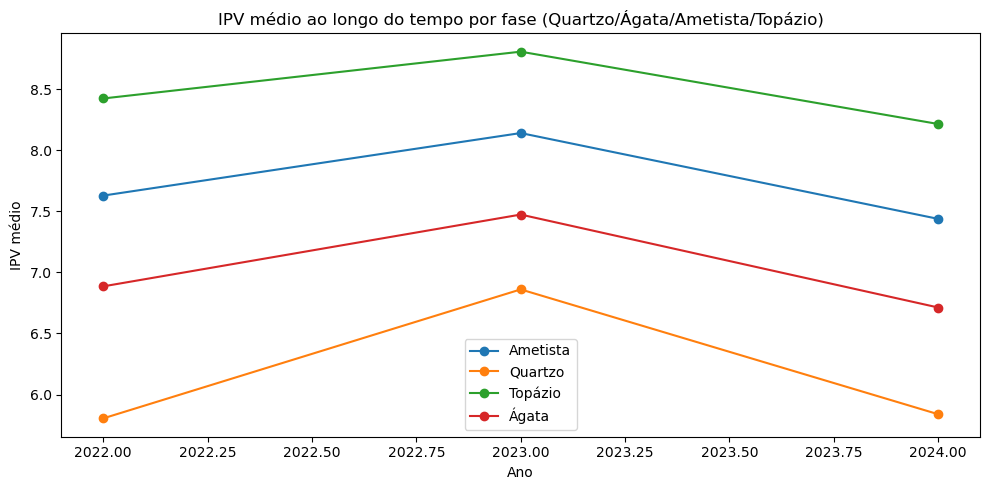

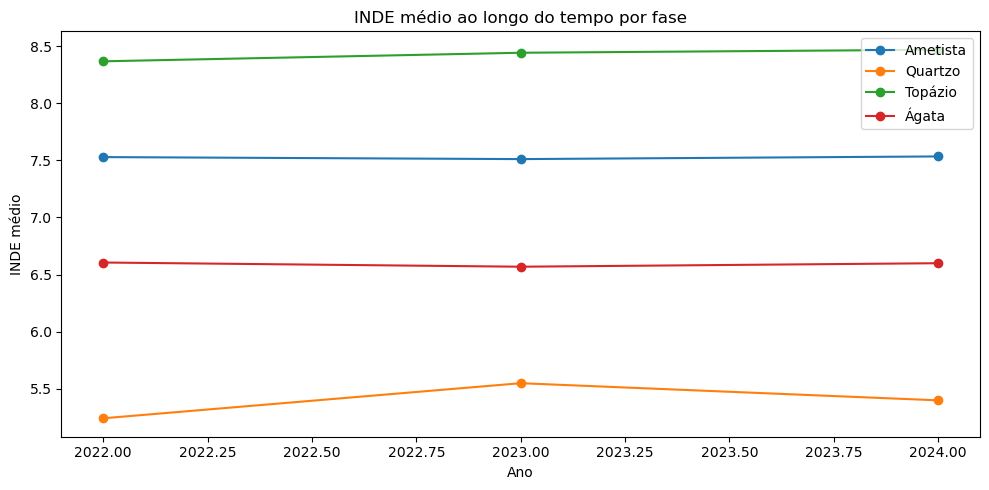

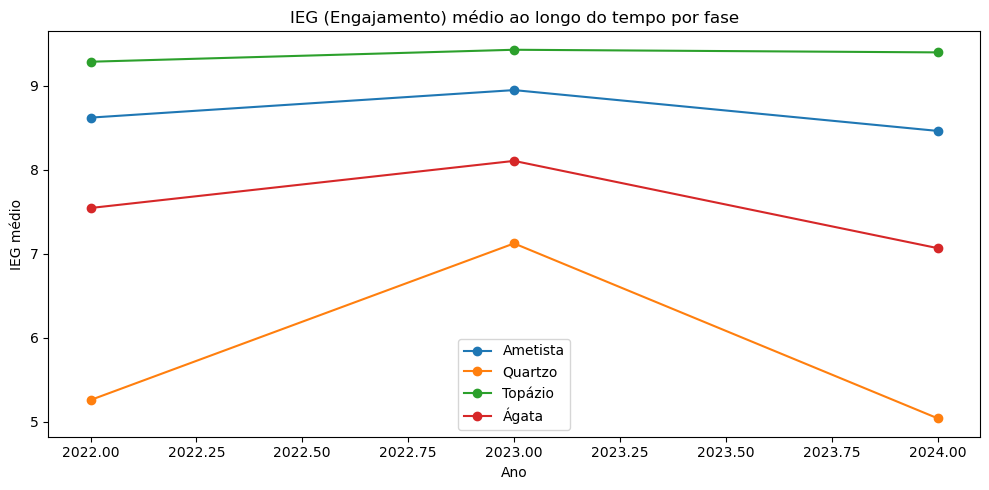

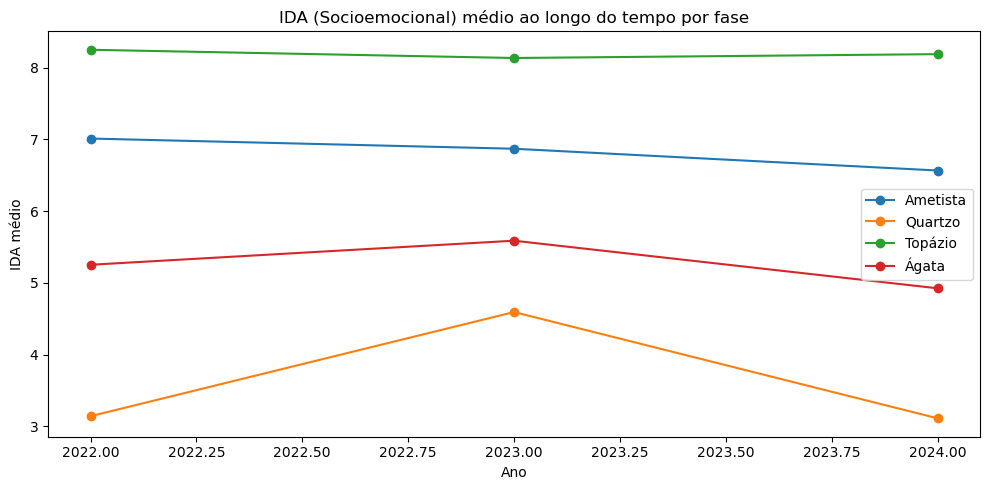

In [14]:
# 7) GRÁFICOS PARA ANÁLISE (inline)

plot_por_fase(
    agg, "ipv", "IPV médio",
    "IPV médio ao longo do tempo por fase (Quartzo/Ágata/Ametista/Topázio)",
    outpath=None
)
plot_por_fase(
    agg, "inde", "INDE médio",
    "INDE médio ao longo do tempo por fase",
    outpath=None
)
plot_por_fase(
    agg, "ieg", "IEG médio",
    "IEG (Engajamento) médio ao longo do tempo por fase",
    outpath=None
)
plot_por_fase(
    agg, "ida", "IDA médio",
    "IDA (Socioemocional) médio ao longo do tempo por fase",
    outpath=None
)


In [15]:
# 8) TABELAS PRINCIPAIS

from IPython.display import display

print("PERGUNTA 10 — tabelas")
print("- agg (fase x ano)")
print("- ipv_d / inde_d / ieg_d / ida_d (deltas por fase)")
print("- detalhe_cons / resumo_cons (consistência por fase)")

display(ipv_d)
display(resumo_cons)


PERGUNTA 10 — tabelas
- agg (fase x ano)
- ipv_d / inde_d / ieg_d / ida_d (deltas por fase)
- detalhe_cons / resumo_cons (consistência por fase)


,Fase (Pedra),2022,2023,2024,Δ2022→2023,Δ2023→2024,Δ2022→2024,Cresceu 2 anos seguidos?
0,Ametista,7.629713,8.142251,7.438920,0.512538,-0.703331,-0.190793,Não
1,Quartzo,5.804394,6.861146,5.838324,1.056752,-1.022821,0.033930,Não
2,Topázio,8.425462,8.808987,8.216254,0.383526,-0.592733,-0.209207,Não
3,Ágata,6.886008,7.474390,6.712841,0.588382,-0.761549,-0.173167,Não


,Fase (Pedra),indicadores_melhoraram,indicadores_sem_queda,Indicadores avaliados,% melhoraram (último>primeiro),% sem queda (sempre subiu)
0,Ametista,1,0,4,0.25,0.00
1,Quartzo,2,0,4,0.50,0.00
2,Topázio,2,1,4,0.50,0.25
3,Ágata,0,0,4,0.00,0.00


In [16]:
# Justificativa pergunta 10

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CAMINHO_ARQUIVO = r"https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
df = pd.read_excel(CAMINHO_ARQUIVO, sheet_name="Sheet1")

ANOS = [2022, 2023, 2024]             # ciclo analisado
ANO_BASE_FASE = 2022                 # define a fase do aluno pela pedra em 2022
FASES_VALIDAS = ["Quartzo", "Ágata", "Ametista", "Topázio"]

MAP_FASE = {"Agata": "Ágata", "Topazio": "Topázio"}

# FUNÇÕES

def normaliza_fase(x):
    s = str(x).strip().title()
    return MAP_FASE.get(s, s)

def resumo_delta_por_fase(df_delta, col_delta, nome_delta):
    g = df_delta.dropna(subset=[col_delta]).groupby("fase_base")
    out = (g[col_delta]
           .agg(
               n="count",
               media="mean",
               mediana="median",
               desvio="std",
               minimo="min",
               maximo="max"
           )
           .reset_index()
           .rename(columns={"fase_base": "Fase (Pedra)"})
           )
    out["Delta"] = nome_delta
    return out

def boxplot_deltas(df_delta, col_delta, titulo, out_png=None):

    data = []
    labels = []
    for fase in sorted(df_delta["fase_base"].dropna().unique()):
        vals = df_delta.loc[df_delta["fase_base"] == fase, col_delta].dropna().values
        if len(vals) > 0:
            data.append(vals)
            labels.append(fase)

    plt.figure(figsize=(10, 5))
    plt.boxplot(data, labels=labels, showmeans=True)
    plt.axhline(0, linestyle="--")  # linha do "sem mudança"
    plt.title(titulo)
    plt.ylabel("Δ IPV")
    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()


In [17]:
df = pd.read_excel(CAMINHO_ARQUIVO, sheet_name="Sheet1")

df["ano"] = pd.to_numeric(df["ano_aba"], errors="coerce")
df["ipv"] = pd.to_numeric(df["ipv"], errors="coerce")
df["fase"] = df["pedra"].apply(normaliza_fase)

# filtra anos e fases
df = df[df["ano"].isin(ANOS)].copy()
df = df[df["fase"].isin(FASES_VALIDAS)].copy()

# 2) IPV POR ALUNO (PIVOT) + FASE BASE

piv = df.pivot_table(index="ra", columns="ano", values="ipv", aggfunc="mean")

fase_base = (df[df["ano"] == ANO_BASE_FASE]
             .groupby("ra")["fase"]
             .first())

piv = piv.merge(fase_base, left_index=True, right_index=True, how="left")
piv = piv.rename(columns={"fase": "fase_base"}).reset_index()

# 3) CALCULA DELTAS
for y in ANOS:
    if y not in piv.columns:
        piv[y] = np.nan

piv["delta_22_23"] = piv[2023] - piv[2022]
piv["delta_23_24"] = piv[2024] - piv[2023]
piv["delta_22_24"] = piv[2024] - piv[2022]

# Preview (base por aluno)
from IPython.display import display
display(piv.head(10))


,ra,2022,2023,2024,fase_base,delta_22_23,delta_23_24,delta_22_24
0,RA-1,7.278,NaN,NaN,Quartzo,NaN,NaN,NaN
1,RA-10,7.056,NaN,NaN,Quartzo,NaN,NaN,NaN
2,RA-100,7.250,NaN,NaN,Ametista,NaN,NaN,NaN
3,RA-1000,NaN,8.920,7.835,NaN,NaN,-1.085,NaN
4,RA-1001,NaN,9.170,7.920,NaN,NaN,-1.250,NaN
5,RA-1002,NaN,8.920,8.250,NaN,NaN,-0.670,NaN
6,RA-1003,NaN,8.750,7.500,NaN,NaN,-1.250,NaN
7,RA-1004,NaN,7.420,7.500,NaN,NaN,0.080,NaN
8,RA-1005,NaN,8.165,NaN,NaN,NaN,NaN,NaN
9,RA-1006,NaN,8.000,7.500,NaN,NaN,-0.500,NaN


In [18]:
# 4) RESUMOS POR FASE

res_22_23 = resumo_delta_por_fase(piv, "delta_22_23", "Δ 2022→2023")
res_23_24 = resumo_delta_por_fase(piv, "delta_23_24", "Δ 2023→2024")
res_22_24 = resumo_delta_por_fase(piv, "delta_22_24", "Δ 2022→2024")

resumo_geral = pd.concat([res_22_23, res_23_24, res_22_24], ignore_index=True)

from IPython.display import display
display(resumo_geral)


,Fase (Pedra),n,media,mediana,desvio,minimo,maximo,Delta
0,Ametista,255,0.500728,0.526333,0.880022,-1.737000,2.757000,Δ 2022→2023
1,Quartzo,48,1.329069,1.447000,1.021067,-1.401500,3.866667,Δ 2022→2023
2,Topázio,110,0.245974,0.256250,0.923259,-2.292000,2.677000,Δ 2022→2023
3,Ágata,157,0.617599,0.672667,0.968261,-1.775500,3.007667,Δ 2022→2023
4,Ametista,204,-0.813731,-0.679167,1.006129,-4.010000,1.655000,Δ 2023→2024
5,Quartzo,26,-0.690378,-0.727417,0.871513,-2.512000,0.874500,Δ 2023→2024
6,Topázio,97,-0.609634,-0.560000,0.965405,-3.616667,2.160000,Δ 2023→2024
7,Ágata,107,-0.870273,-0.717500,1.139730,-3.938333,1.745000,Δ 2023→2024
8,Ametista,206,-0.287587,-0.231833,1.065472,-4.723667,2.233000,Δ 2022→2024
9,Quartzo,27,0.707296,0.389333,1.195998,-1.104500,3.314667,Δ 2022→2024


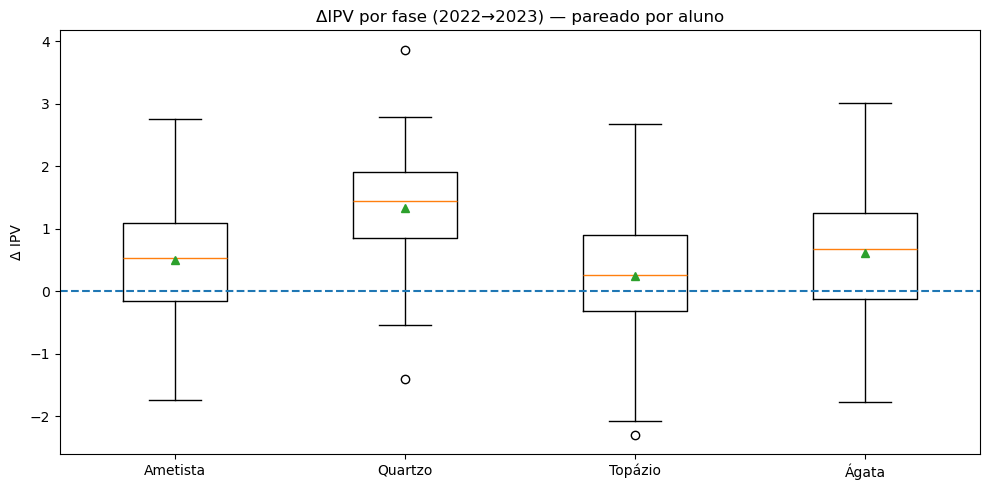

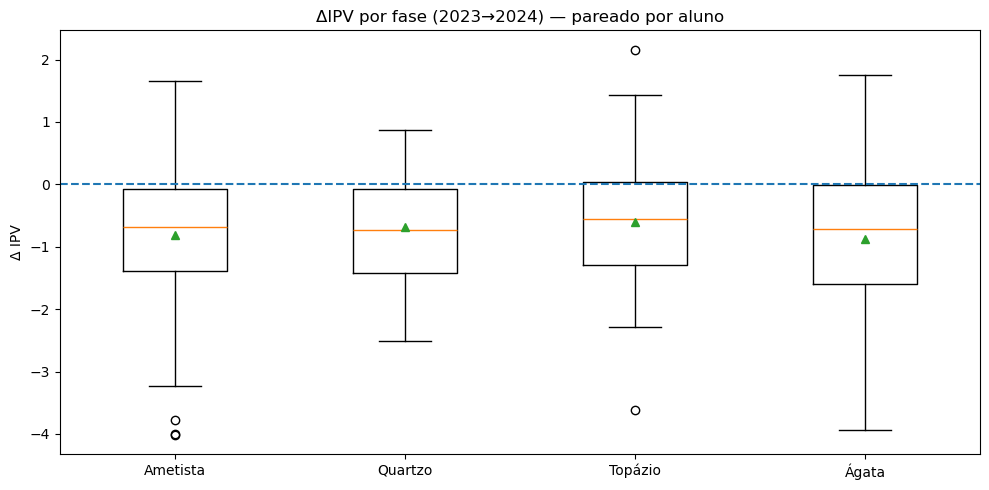

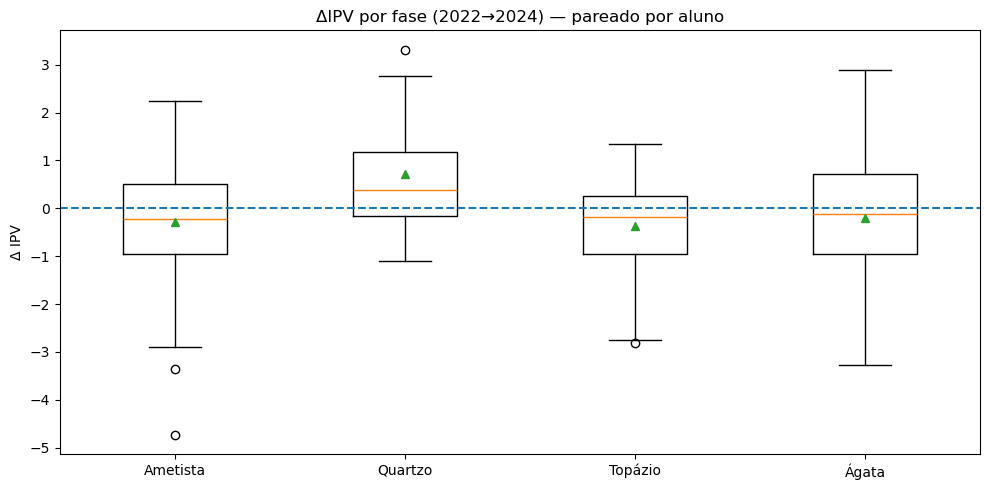

In [19]:
# 5) GRÁFICOS

boxplot_deltas(
    piv, "delta_22_23",
    "ΔIPV por fase (2022→2023) — pareado por aluno",
    out_png=None
)
boxplot_deltas(
    piv, "delta_23_24",
    "ΔIPV por fase (2023→2024) — pareado por aluno",
    out_png=None
)
boxplot_deltas(
    piv, "delta_22_24",
    "ΔIPV por fase (2022→2024) — pareado por aluno",
    out_png=None
)


In [20]:
from IPython.display import display

print("\nPAREADO POR ALUNO (RA) — principais variáveis:")
print("- piv (IPV por aluno + deltas)")
print("- resumo_geral (resumo por fase, por delta)")

print("\n--- Resumo Geral (primeiras linhas) ---")
display(resumo_geral.head(20))



PAREADO POR ALUNO (RA) — principais variáveis:
- piv (IPV por aluno + deltas)
- resumo_geral (resumo por fase, por delta)

--- Resumo Geral (primeiras linhas) ---


,Fase (Pedra),n,media,mediana,desvio,minimo,maximo,Delta
0,Ametista,255,0.500728,0.526333,0.880022,-1.737000,2.757000,Δ 2022→2023
1,Quartzo,48,1.329069,1.447000,1.021067,-1.401500,3.866667,Δ 2022→2023
2,Topázio,110,0.245974,0.256250,0.923259,-2.292000,2.677000,Δ 2022→2023
3,Ágata,157,0.617599,0.672667,0.968261,-1.775500,3.007667,Δ 2022→2023
4,Ametista,204,-0.813731,-0.679167,1.006129,-4.010000,1.655000,Δ 2023→2024
5,Quartzo,26,-0.690378,-0.727417,0.871513,-2.512000,0.874500,Δ 2023→2024
6,Topázio,97,-0.609634,-0.560000,0.965405,-3.616667,2.160000,Δ 2023→2024
7,Ágata,107,-0.870273,-0.717500,1.139730,-3.938333,1.745000,Δ 2023→2024
8,Ametista,206,-0.287587,-0.231833,1.065472,-4.723667,2.233000,Δ 2022→2024
9,Quartzo,27,0.707296,0.389333,1.195998,-1.104500,3.314667,Δ 2022→2024


### RESUMO ###

In [21]:
# Relatório final - Pergunta 7

from IPython.display import display

print("\n==================== RESULTADOS ====================")
print(f"[LAG1] R² teste = {r2_lag:.3f} | MAE teste = {mae_lag:.3f} | n = {len(lag_data)}")
print("Top 8 (lag1):")
print(imp_lag.head(8).to_string(index=False))

print("\n----------------------------------------------------")
print(f"[DELTA] R² teste = {r2_delta:.3f} | MAE teste = {mae_delta:.3f} | n = {len(delta_data)}")
print("Top 8 (delta):")
print(imp_delta.head(8).to_string(index=False))

print("\n----------------------------------------------------")
print("Resumo uplift (Q1 -> Q4):")
display(resumo_df.sort_values("delta_q4_q1", ascending=False))



==================== RESULTADOS ====================
[LAG1] R² teste = 0.350 | MAE teste = 0.693 | n = 678
Top 8 (lag1):
      feature  importance_mean  importance_std feature_clean
inde_num_lag1         3.191734        0.353822      inde_num
     iaa_lag1         0.415389        0.070163           iaa
     ida_lag1         0.141801        0.033382           ida
     ieg_lag1         0.085413        0.021248           ieg
     ips_lag1         0.059274        0.029199           ips
     ian_lag1         0.040922        0.016139           ian
     ipp_lag1         0.001040        0.008004           ipp

----------------------------------------------------
[DELTA] R² teste = 0.999 | MAE teste = 0.025 | n = 678
Top 8 (delta):
       feature  importance_mean  importance_std feature_clean
delta_inde_num        31.453127        1.920216      inde_num
     delta_ida         5.948196        0.510018           ida
     delta_iaa         4.960609        0.321645           iaa
     delta_ieg    

,indicador,ipv_q1,ipv_q4,delta_q4_q1
0,inde_num,6.508284,8.441638,1.933354
5,ipp,6.811824,8.467362,1.655539
2,ida,6.674348,8.285430,1.611082
1,ieg,6.710492,8.215071,1.504580
4,ips,7.624111,7.981164,0.357054
3,iaa,7.335264,7.691983,0.356719
6,ian,7.420423,7.726608,0.306185


Resposta da Pergunta 7

Os resultados indicam que o principal fator que influencia o IPV ao longo do tempo é o componente acadêmico, especialmente o INDE. No modelo temporal (LAG), o INDE do ano anterior é o preditor mais forte do IPV do ano seguinte, enquanto indicadores de engajamento (IEG) e socioemocionais (IDA/IPS/IAN) contribuem, mas com impacto menor. No modelo de variação (DELTA), a mudança no INDE (ΔINDE) é o maior “motor” do ponto de virada do IPV, reforçada por mudanças em IDA (socioemocional) e IEG (engajamento). A análise por quartis confirma esse padrão: alunos nos quartis mais altos de INDEs tendem a ter o IPV significativamente maior do que os quartis mais baixos.

In [22]:
# Relatório - Pergunta 10 

from IPython.display import display

print("\nPERGUNTA 10 - RESUMO")

print("\n--- DELTAS IPV POR FASE ---")
print(ipv_d.to_string(index=False))

print("\n--- RESUMO DE CONSISTÊNCIA (IPV/INDE/IEG/IDA) ---")
display(resumo_cons)




PERGUNTA 10 - RESUMO

--- DELTAS IPV POR FASE ---
Fase (Pedra)     2022     2023     2024  Δ2022→2023  Δ2023→2024  Δ2022→2024 Cresceu 2 anos seguidos?
    Ametista 7.629713 8.142251 7.438920    0.512538   -0.703331   -0.190793                      Não
     Quartzo 5.804394 6.861146 5.838324    1.056752   -1.022821    0.033930                      Não
     Topázio 8.425462 8.808987 8.216254    0.383526   -0.592733   -0.209207                      Não
       Ágata 6.886008 7.474390 6.712841    0.588382   -0.761549   -0.173167                      Não

--- RESUMO DE CONSISTÊNCIA (IPV/INDE/IEG/IDA) ---


,Fase (Pedra),indicadores_melhoraram,indicadores_sem_queda,Indicadores avaliados,% melhoraram (último>primeiro),% sem queda (sempre subiu)
0,Ametista,1,0,4,0.25,0.00
1,Quartzo,2,0,4,0.50,0.00
2,Topázio,2,1,4,0.50,0.25
3,Ágata,0,0,4,0.00,0.00


Resposta da Pergunta 10

Os indicadores não mostram melhora consistente ao longo de todo o ciclo nas fases (Quartzo, Ágata, Ametista e Topázio). Em geral, há ganho de 2022→2023, mas esse avanço não se sustenta em 2023→2024, quando ocorre queda em todas as fases, tanto na média por fase quanto na análise pareada por aluno (RA). No acumulado 2022→2024, apenas Quartzo permanece levemente positivo, enquanto as demais fases ficam estáveis/negativas. Portanto, os dados sugerem um efeito positivo pontual (no primeiro intervalo), mas sem evidência de melhora contínua que confirme impacto real sustentado do programa ao longo do ciclo.